In [ ]:
! pip install scikit-learn

In [3]:
import pandas
import seaborn

In [7]:
# url = "https://raw.githubusercontent.com/dragonnomada/ml-cic-febrero-2026/refs/heads/main/titanic.csv"

# titanic = pandas.read_csv(url)

titanic = pandas.read_csv("titanic.csv", usecols=["Survived", "Age", "Sex", "Pclass", "Embarked", "Fare", "SibSp", "Parch", "Cabin"])

titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [30]:
y = titanic["Survived"] # Respuesta categórica (2 clases / binaria)

<Axes: xlabel='Age', ylabel='Density'>

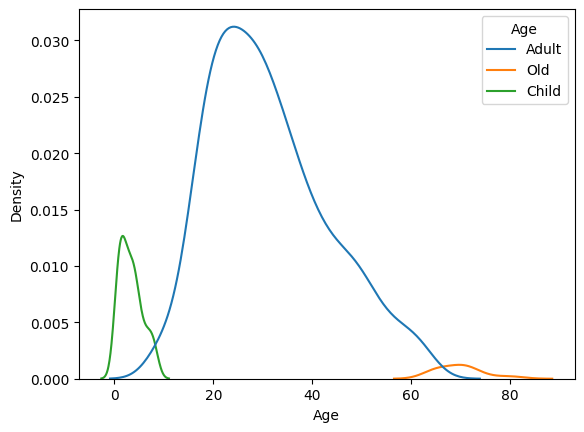

In [ ]:
x1 = titanic["Age"] # Informativa numérica (positiva)

import numpy

def grupoEdad(age):
    if age == numpy.nan:
        return numpy.nan
    if age <= 8:
        return "Child"
    elif age < 65:
        return "Adult"
    else:
        return "Old"

x2 = x1.map(grupoEdad)

seaborn.kdeplot(x=x1, hue=x2)

<Axes: xlabel='Age', ylabel='Density'>

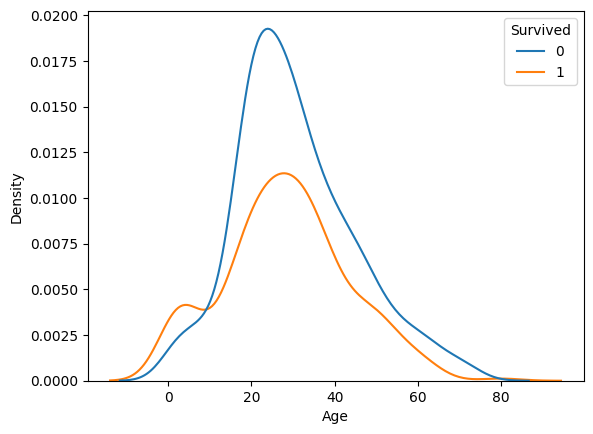

In [38]:
# y vs x1
# categórico vs numérico (cat-num)

seaborn.kdeplot(x=x1, hue=y)

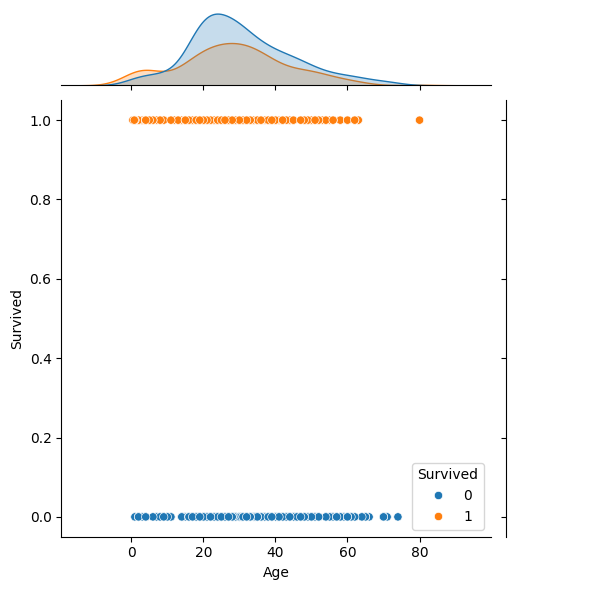

In [64]:
seaborn.jointplot(x=x1, y=y, hue=y)

In [48]:
# y vs x2
# categórica vs categórica (cat-cat)

r1 = pandas.DataFrame([x2, y]).T.value_counts().unstack()
r1

Survived,0,1
Age,,
Adult,396,253
Child,18,36
Old,135,53


In [49]:
r1.div(r1.sum(axis=1), axis=0)

Survived,0,1
Age,,
Adult,0.610169,0.389831
Child,0.333333,0.666667
Old,0.718085,0.281915


<Axes: xlabel='Survived', ylabel='Age'>

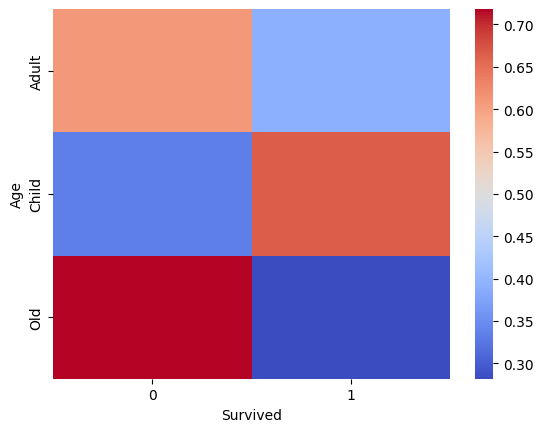

In [51]:
seaborn.heatmap(r1.div(r1.sum(axis=1), axis=0), cmap="coolwarm")

<Axes: xlabel='Survived', ylabel='Age'>

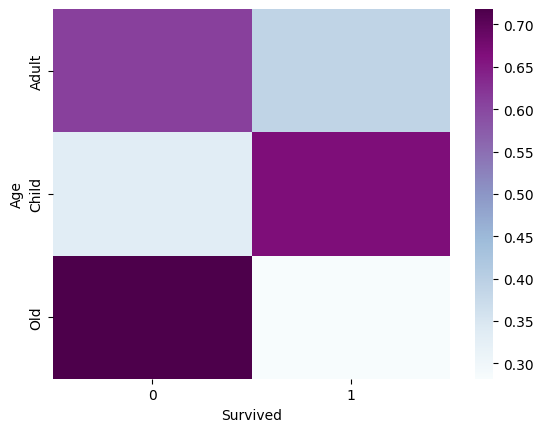

In [61]:
seaborn.heatmap(r1.div(r1.sum(axis=1), axis=0), cmap="BuPu")

In [73]:
x2.value_counts()

Age
Adult    649
Old      188
Child     54
Name: count, dtype: int64

In [88]:
X = pandas.DataFrame([x1, x2 == "Child", x2 == "Old"], index=["age", "child", "old"]).T.dropna()

X.sample(10)

,age,child,old
661,40.0,0.0,0.0
687,19.0,0.0,0.0
852,9.0,0.0,0.0
453,49.0,0.0,0.0
478,22.0,0.0,0.0
360,40.0,0.0,0.0
492,55.0,0.0,0.0
294,24.0,0.0,0.0
352,15.0,0.0,0.0
147,9.0,0.0,0.0


In [83]:
X.shape

(714, 3)

In [92]:
y1 = y[X.index]

y1.shape

(714,)

##  Árboles de decisión

In [96]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

model = DecisionTreeClassifier(
    max_depth=4
)

model.fit(X, y1)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


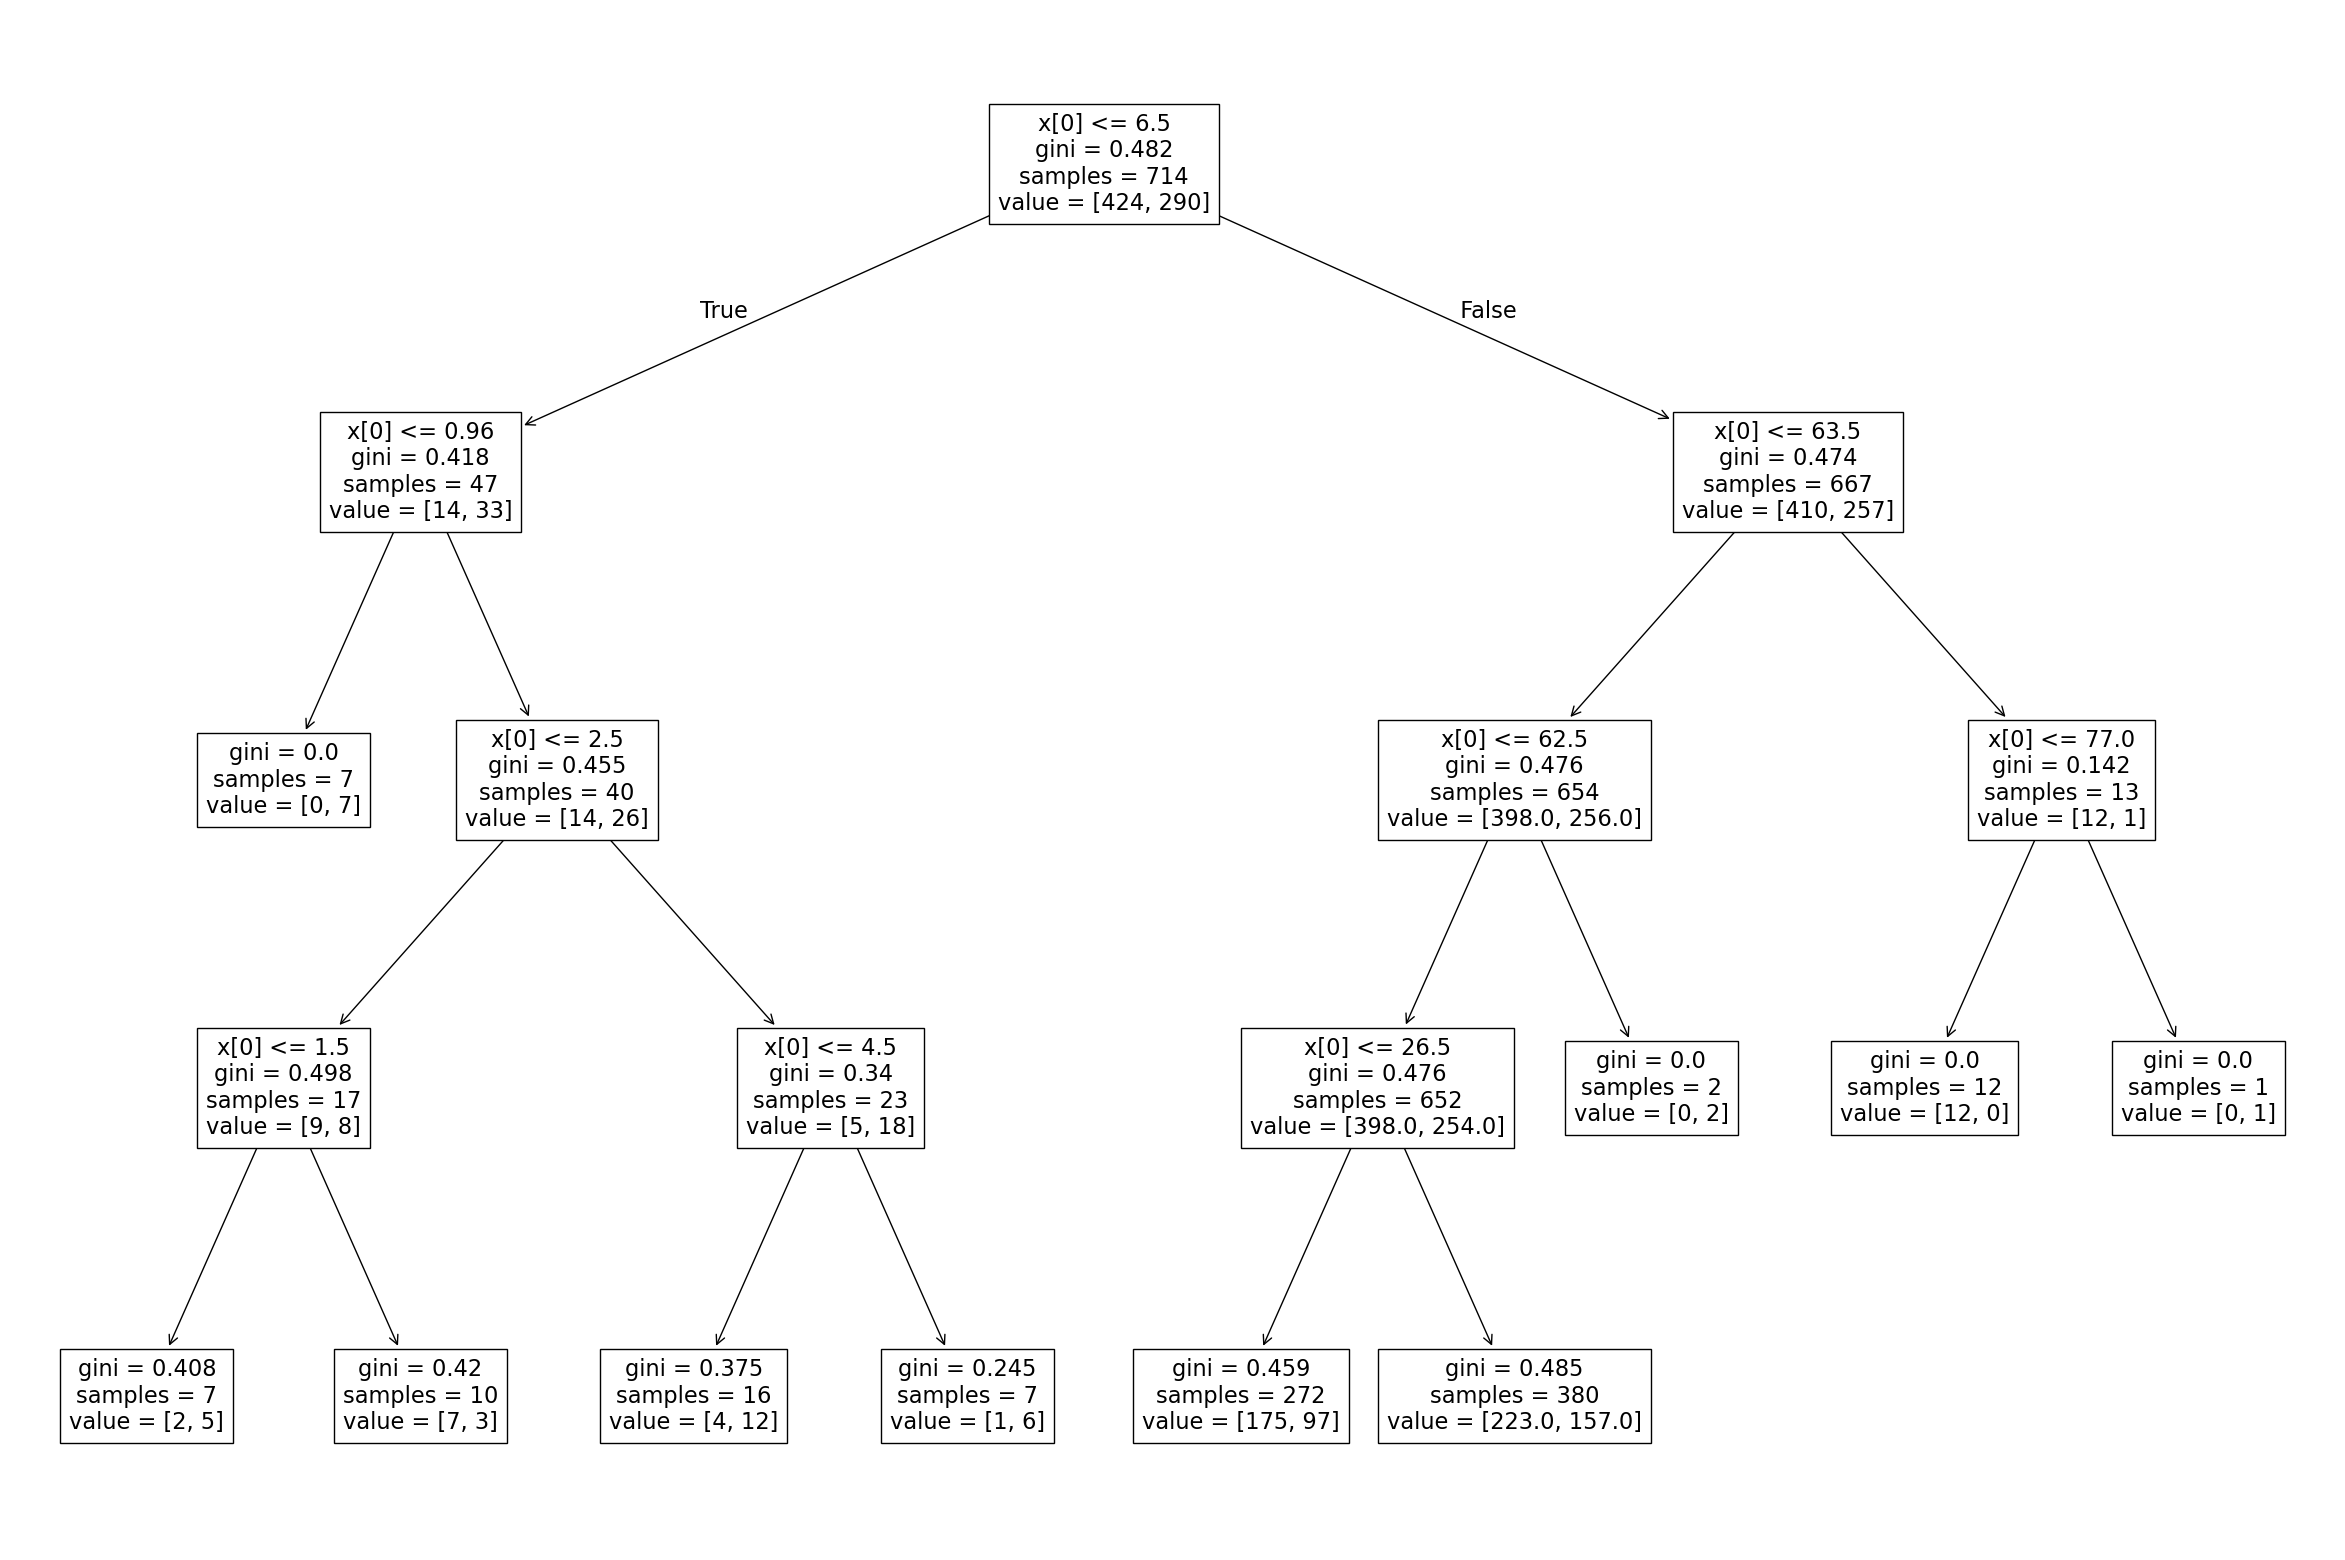

In [100]:
from matplotlib import pyplot

figure, axes = pyplot.subplots(figsize=(30, 20))

plot_tree(model, ax=axes)

pyplot.show()

In [103]:
y1p = model.predict(X)

pandas.DataFrame({
    "y": y1,
    "yp": y1p
})

,y,yp
0,0,0
1,1,0
2,1,0
3,1,0
4,0,0
...,...,...
885,0,0
886,0,0
887,1,0
889,1,0


<Axes: >

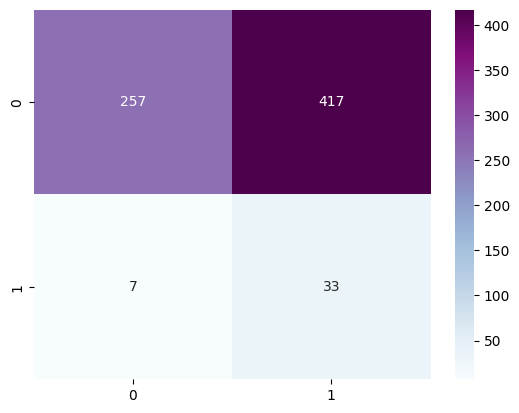

In [132]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y1, y1p).ravel()

seaborn.heatmap([
    [fn, tn],
    [fp, tp],
], cmap="BuPu", annot=True, fmt=".0f")

In [134]:
p = tp / (tp + fp) # La precisión para decir que alguien sobrevive
s = tp / (tp + fn) # La sensibilidad 
f1 = 2 * (p * s) / (p + s)
e = tn / (tn + fp)
a = (tp + tn) / (tp + tn + fn + fp)

pandas.DataFrame({
    "accuracy": [a],
    "Precision": [p],
    "Sensivity": [s],
    "Specificity": [e],
    "f1-score": [f1],
}).T

,0
accuracy,0.630252
Precision,0.825000
Sensivity,0.113793
Specificity,0.983491
f1-score,0.200000


## Curva logística

In [140]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression()

model2.fit(X, y1)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [141]:
y1p = model2.predict(X)

pandas.DataFrame({
    "y": y1,
    "yp": y1p
})

,y,yp
0,0,0
1,1,0
2,1,0
3,1,0
4,0,0
...,...,...
885,0,0
886,0,0
887,1,0
889,1,0


<Axes: >

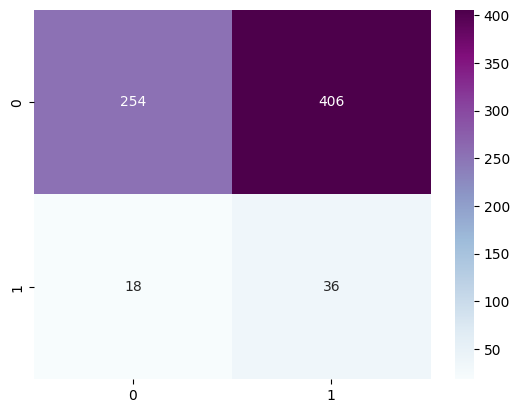

In [143]:
tn, fp, fn, tp = confusion_matrix(y1, y1p).ravel()

seaborn.heatmap([
    [fn, tn],
    [fp, tp],
], cmap="BuPu", annot=True, fmt=".0f")

In [144]:
p = tp / (tp + fp) # La precisión para decir que alguien sobrevive
s = tp / (tp + fn) # La sensibilidad 
f1 = 2 * (p * s) / (p + s)
e = tn / (tn + fp)
a = (tp + tn) / (tp + tn + fn + fp)

pandas.DataFrame({
    "accuracy": [a],
    "Precision": [p],
    "Sensivity": [s],
    "Specificity": [e],
    "f1-score": [f1],
}).T

,0
accuracy,0.619048
Precision,0.666667
Sensivity,0.124138
Specificity,0.957547
f1-score,0.209302


<Axes: xlabel='age', ylabel='Survived'>

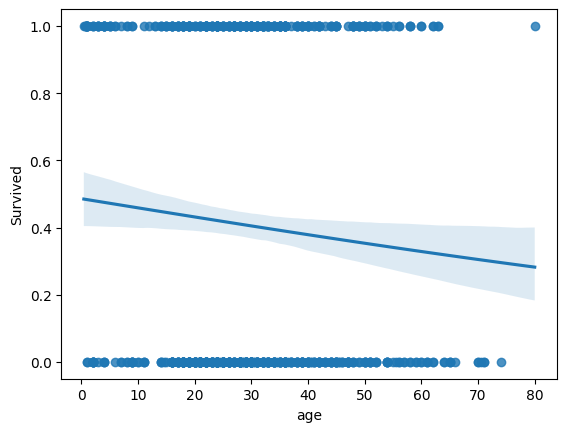

In [148]:
seaborn.regplot(x=X["age"], y=y1, logistic=True)

## Más características

In [156]:
titanic["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [159]:
x3 = titanic["Sex"] == "female"
x4 = titanic["Pclass"] == 1
x5 = titanic["Pclass"] == 2
x6 = ~titanic["Cabin"].isna()

In [161]:
X = pandas.DataFrame([x1, x2 == "Child", x2 == "Old", x3, x4, x5, x6], index=["age", "child", "old", "female", "1-class", "2-class", "cabin"]).T.dropna()

X

,age,child,old,female,1-class,2-class,cabin
0,22.0,0.0,0.0,0.0,0.0,0.0,0.0
1,38.0,0.0,0.0,1.0,1.0,0.0,1.0
2,26.0,0.0,0.0,1.0,0.0,0.0,0.0
3,35.0,0.0,0.0,1.0,1.0,0.0,1.0
4,35.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
885,39.0,0.0,0.0,1.0,0.0,0.0,0.0
886,27.0,0.0,0.0,0.0,0.0,1.0,0.0
887,19.0,0.0,0.0,1.0,1.0,0.0,1.0
889,26.0,0.0,0.0,0.0,1.0,0.0,1.0


In [162]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

model = DecisionTreeClassifier(
    max_depth=4
)

model.fit(X, y1)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


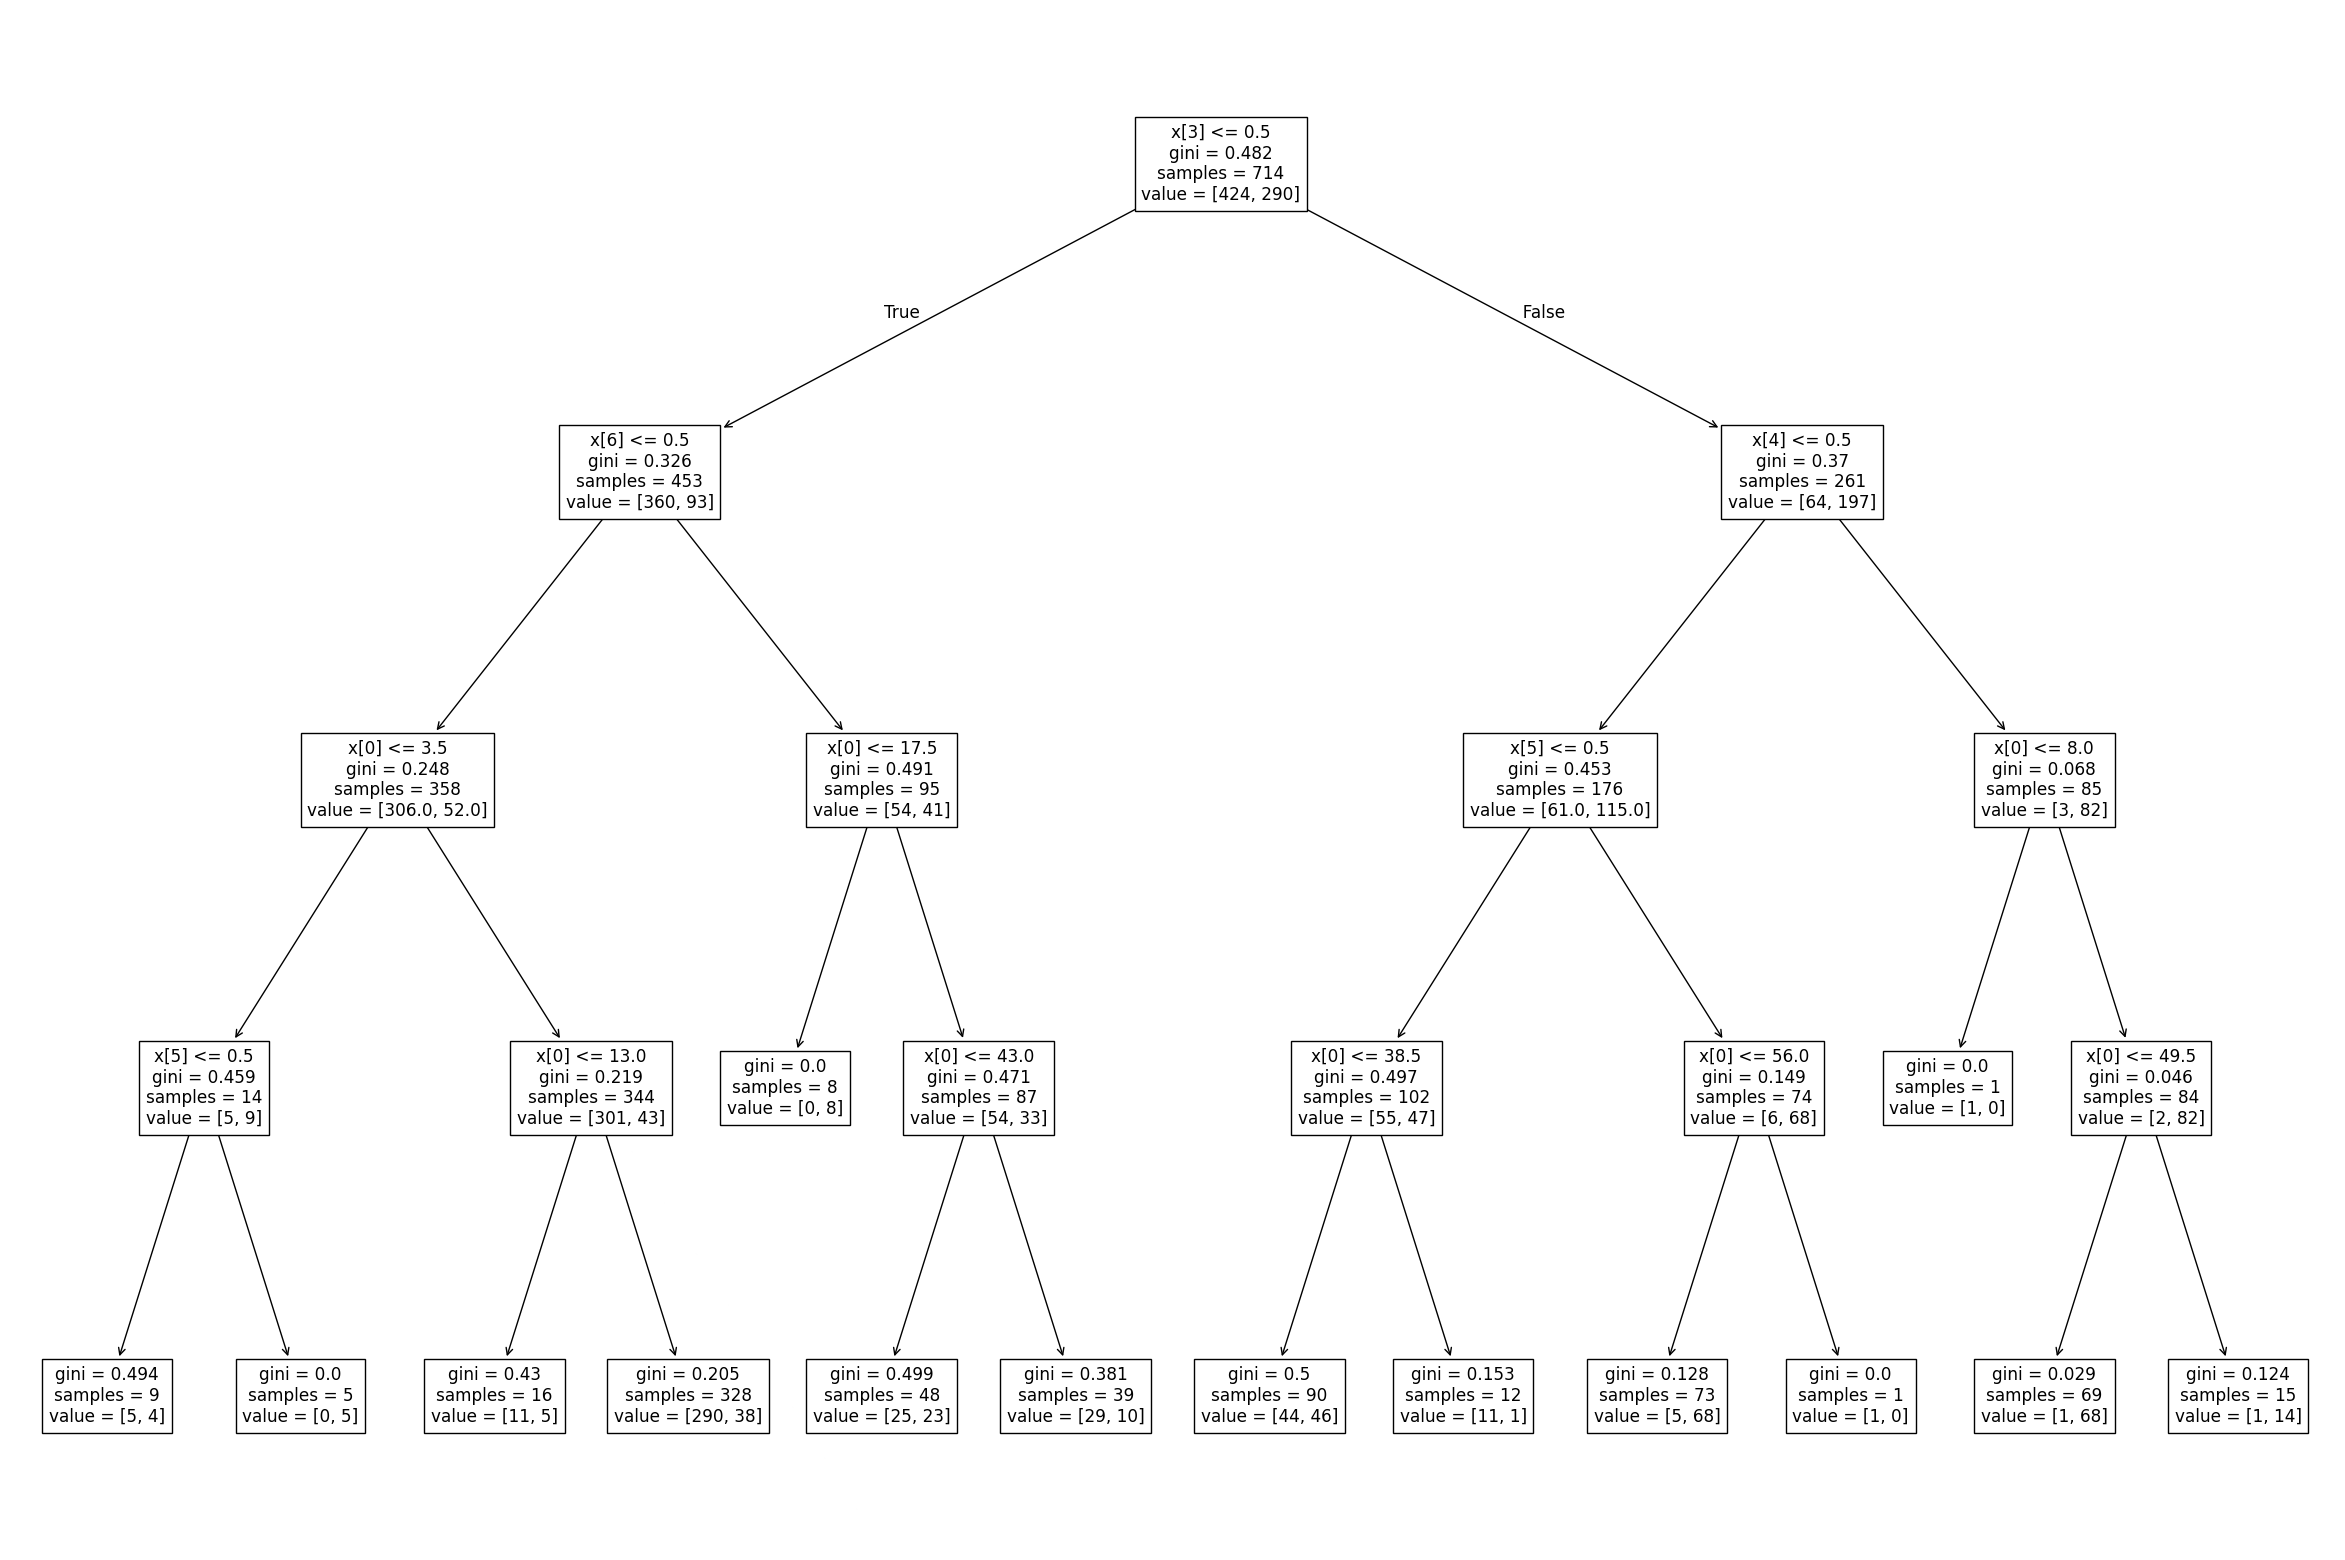

In [163]:
from matplotlib import pyplot

figure, axes = pyplot.subplots(figsize=(30, 20))

plot_tree(model, ax=axes)

pyplot.show()

In [164]:
y1p = model.predict(X)

pandas.DataFrame({
    "y": y1,
    "yp": y1p
})

,y,yp
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0
...,...,...
885,0,0
886,0,0
887,1,1
889,1,0


<Axes: >

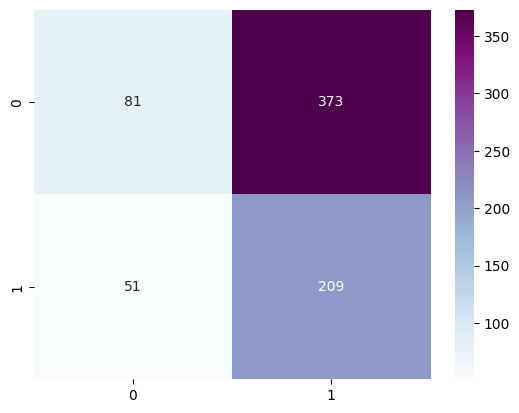

In [165]:
tn, fp, fn, tp = confusion_matrix(y1, y1p).ravel()

seaborn.heatmap([
    [fn, tn],
    [fp, tp],
], cmap="BuPu", annot=True, fmt=".0f")

In [166]:
p = tp / (tp + fp) # La precisión para decir que alguien sobrevive
s = tp / (tp + fn) # La sensibilidad 
f1 = 2 * (p * s) / (p + s)
e = tn / (tn + fp)
a = (tp + tn) / (tp + tn + fn + fp)

pandas.DataFrame({
    "accuracy": [a],
    "Precision": [p],
    "Sensivity": [s],
    "Specificity": [e],
    "f1-score": [f1],
}).T

,0
accuracy,0.815126
Precision,0.803846
Sensivity,0.720690
Specificity,0.879717
f1-score,0.760000


In [167]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression()

model2.fit(X, y1)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [168]:
y1p = model2.predict(X)

pandas.DataFrame({
    "y": y1,
    "yp": y1p
})

,y,yp
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0
...,...,...
885,0,0
886,0,0
887,1,1
889,1,1


<Axes: >

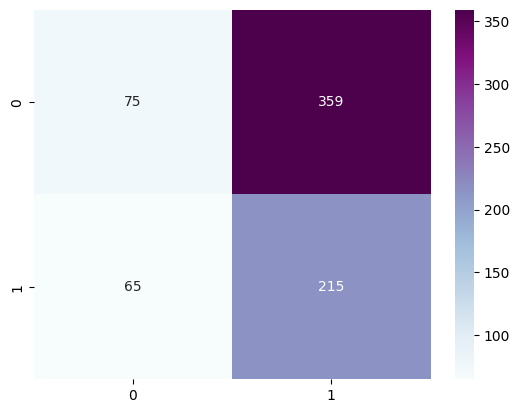

In [169]:
tn, fp, fn, tp = confusion_matrix(y1, y1p).ravel()

seaborn.heatmap([
    [fn, tn],
    [fp, tp],
], cmap="BuPu", annot=True, fmt=".0f")

In [170]:
p = tp / (tp + fp) # La precisión para decir que alguien sobrevive
s = tp / (tp + fn) # La sensibilidad 
f1 = 2 * (p * s) / (p + s)
e = tn / (tn + fp)
a = (tp + tn) / (tp + tn + fn + fp)

pandas.DataFrame({
    "accuracy": [a],
    "Precision": [p],
    "Sensivity": [s],
    "Specificity": [e],
    "f1-score": [f1],
}).T

,0
accuracy,0.803922
Precision,0.767857
Sensivity,0.741379
Specificity,0.846698
f1-score,0.754386
